# New science concepts and their papers: dataset builder demo

This notebook is a runnable walk-through of **`data.py`**, the script that standardises the
*concept pool 2005–2016* artifact into the `exp_sel_data_out` schema (**one example per data row, grouped by dataset**).

**What the artifact is.** It is an outcome-blind pool of emerging scientific concepts: noun phrases first used between
2005 and 2016, detected from OpenAlex title and abstract surface-form counts. The sampling frame was frozen and
sha256-hashed before any data from later than the first-use year F+2 was looked at. A stationary **reference arm** of
established concepts is included, and every concept comes with its **complete OpenAlex work list for 2000–2024**.
The full artifact holds five datasets:

| dataset | source file | one row = | output |
|---|---|---|---|
| `concept_pool_2005_2016` | `data_out.json` | concept (206 = 184 main + 22 reference) | `oa_counts_by_year` + `work_ids` |
| `concept_work_links` | `concept_work.parquet` | verified concept→work link (214,798) | match evidence |
| `openalex_works` | `works/*.parquet` | OpenAlex work (208,374) | primary-topic subfield id |
| `subfield_year_totals` | `context/subfield_year_totals.json` | (variant, year, subfield) | count |
| `venue_habitat` | `context/venue_habitat.json` | venue (15,261) | dominant subfield |

**What this demo runs.** `mini_demo_data.json` is a stratified **100-concept subset** of the first (core) dataset,
`concept_pool_2005_2016`, stored in exactly the same structure as the original `data_out.json`. The notebook runs
the original builder for that dataset end to end, writes `full_data_out.json`, and then plots the concepts' OpenAlex
uptake trajectories. The other four builders are included verbatim, but they need the multi-hundred-MB parquet and
context files from the full artifact workspace, so the config cell leaves them switched off.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# orjson, loguru — NOT pre-installed on Colab, always install
_pip('orjson==3.11.3', 'loguru==0.7.3')

# numpy, pandas, pyarrow, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

## Imports
The original `data.py` import block, unchanged, followed by the extra imports this notebook needs for loading the
demo data and plotting.

In [2]:
# --- original data.py imports ---
import sys
from pathlib import Path

import orjson
import pandas as pd
import pyarrow.parquet as pq
from loguru import logger

# --- extra imports for the notebook (data loading + visualisation) ---
import json
import numpy as np
import matplotlib.pyplot as plt

## Load the demo data
`mini_demo_data.json` has the same layout as the artifact's `data_out.json`
(`{"metadata": ..., "datasets": [{"dataset": "concept_pool_2005_2016", "examples": [...]}]}`).
The notebook first tries the GitHub copy and falls back to a local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-1/dataset-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("demo subset:", data["metadata"].get("demo_subset"))
print({d["dataset"]: len(d["examples"]) for d in data["datasets"]})

Outcome-blind pool of scientific concepts first used 2005-2016 (main arm) plus a stationary reference arm, with complete OpenAlex work lists 2000-2024. See README.md.
demo subset: 100 of 206 concepts (stratified by arm, fold, F_band, origin field; seed 0)
{'concept_pool_2005_2016': 100}


## Configuration
All tunable parameters for the demo are set here.

* `MAX_CONCEPTS` sets how many concepts from the loaded pool are exported. The demo data holds 100; the original run
  used all 206 concepts from `data_out.json`.
* `DATASETS_TO_BUILD` lists the builders `main()` runs. The original value is `BEST5` (all five datasets). Only
  `concept_pool_2005_2016` is part of the demo data; the other four need the artifact's parquet and context files
  under `ROOT`.
* `PART_LIMIT` is the size threshold (in bytes) above which the export is split into
  `full_data_out/full_data_out_N.json`. It is the same as in the original.

In [5]:
MAX_CONCEPTS = 100          # original: all concepts (206 in the full data_out.json); demo data holds 100
DATASETS_TO_BUILD = ["concept_pool_2005_2016"]
# original: DATASETS_TO_BUILD = BEST5  (needs concept_work.parquet, works/*.parquet, context/*.json from the artifact)
PART_LIMIT = 90_000_000     # original: 90_000_000

## Script setup
These are the module-level constants and logging from `data.py`. The only change: `ROOT` was
`Path(__file__).resolve().parent`, and a notebook has no `__file__`, so it is now the current working directory.
Logs go to stdout and to `logs/data.log`, as in the original.

In [6]:
"""Standardise the candidate datasets to the exp_sel_data_out schema, ONE EXAMPLE PER DATA ROW, grouped by dataset.

Artifact datasets (built by this repo; canonical files at the workspace root):
  concept_pool_2005_2016   D1  data_out.json            1 row / concept      output = oa_counts_by_year+work_ids (JSON)
  concept_work_links       D3  concept_work.parquet     1 row / link         output = match_evidence
  openalex_works           D2  works/*.parquet          1 row / work         output = primary-topic subfield_id
  subfield_year_totals     D4  context/subfield_year_totals.json  1 row / (variant, year, subfield)  output = count
  venue_habitat            D5  context/venue_habitat.json         1 row / venue  output = dominant_subfield
(The 5 labelled HF grounding sets in temp/datasets/ were evaluated in an earlier version and not selected.)

Usage: uv run data.py   -> full_data_out.json, split into full_data_out/full_data_out_N.json when > 90 MB"""
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
# PART_LIMIT = 90_000_000  -> set in the config cell
BEST5 = ["concept_pool_2005_2016", "concept_work_links", "openalex_works", "subfield_year_totals", "venue_habitat"]

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

J = lambda o: orjson.dumps(o).decode()  # noqa: E731

## D1: concept pool (the dataset this demo runs)
`data_out.json` already stores one example per concept, so this builder mostly passes rows through:

* **`input`** (JSON string): `phrase`, `surface_forms`, first-use year `F`, the outcome-blind `screen_counts_by_year`
  (up to F+2), early volume `early_volume_V`, and the origin field and subfield.
* **`output`** (JSON string): `oa_counts_by_year` for 2000–2024, `s2_counts_by_year`, `n_works` and the complete
  `work_ids` list.
* **`metadata_*`**: fold (`screen` / `heldout_concept` / `reference`), `F_band`, volume tercile, focal years,
  retrieval route, flags, and so on.

`concept_meta()` indexes the same rows by concept id; the link builder uses it to look up each link's fold.
Change from the original: the file read `orjson.loads((ROOT / "data_out.json").read_bytes())` is replaced by the
`data` loaded above, and the result is capped at `MAX_CONCEPTS`.

In [7]:
def concept_meta() -> dict:
    d = data  # original: orjson.loads((ROOT / "data_out.json").read_bytes())
    return {e["metadata_concept_id"]: e for e in d["datasets"][0]["examples"][:MAX_CONCEPTS]}


def ds_concept_pool() -> list[dict]:
    d = data  # original: orjson.loads((ROOT / "data_out.json").read_bytes())
    return d["datasets"][0]["examples"][:MAX_CONCEPTS]

## D2–D5: link, work, denominator and venue builders (original code, not run in the demo)
These four builders are copied unchanged. They read the large artifact files under `ROOT`: `concept_work.parquet`,
`works/works_part_*.parquet`, `context/subfield_year_totals.json` with `taxonomy.json`, and
`context/venue_habitat.json`. To keep the output small, `concept_work_links` and `openalex_works` store `input`
as a positional JSON array; the column names are listed once in `TOP_META["feature_names"]`.

* **`ds_links`**: one row per verified concept→work link; `output` is the match evidence (title, abstract or
  index-only).
* **`ds_works`**: one row per OpenAlex work; `output` is its primary-topic subfield id. This is the discipline
  label for the concept–discipline network.
* **`ds_denominators`**: subfield × year totals in four variants, used for per-10⁴ normalisation.
* **`ds_venues`**: venue "habitat" with subfield shares, dominant subfield and megajournal/coverage flags.

In [8]:
LINK_FEATURES = ["concept_id", "work_id", "year"]


def ds_links(cm: dict) -> list[dict]:
    """input = JSON array ordered as LINK_FEATURES (names in top-level metadata to keep the file small)."""
    cw = pd.read_parquet(ROOT / "concept_work.parquet")
    out = []
    for i, r in enumerate(cw.itertuples(index=False)):
        c = cm[r.concept_id]
        out.append({"input": J([r.concept_id, int(r.work_id), int(r.year)]), "output": str(r.match_evidence),
                    "metadata_fold": c["metadata_fold"], "metadata_matched_form": r.matched_form,
                    "metadata_dup_group": None if pd.isna(r.dup_group) else int(r.dup_group)})
    return out


WORK_FEATURES = ["work_id", "publication_year", "type", "language", "doi_present", "s2_corpus_id", "primary_topic_id",
                 "topic_score", "topics_top3", "source_id", "source_type", "n_refs", "refs_in_corpus", "author_ids",
                 "keyword_idx", "concept_ids", "has_abstract", "abstract_n_tokens", "cited_by_count", "dup_group"]


def ds_works() -> list[dict]:
    """input = JSON array ordered as WORK_FEATURES; output = primary-topic subfield id (ASJC-style) or 'unknown'.
    Full referenced_works, institution_ids and keyword/concept scores stay in works/works_part_XX.parquet."""
    out = []
    cols = WORK_FEATURES + ["subfield_id", "field_id", "domain_id"]
    for p in sorted((ROOT / "works").glob("works_part_*.parquet")):
        for r in pq.read_table(p, columns=cols).to_pylist():
            if r["topic_score"] is not None:
                r["topic_score"] = round(float(r["topic_score"]), 4)
            sf = r["subfield_id"]
            out.append({"input": J([r[k] for k in WORK_FEATURES]), "output": str(sf) if sf is not None else "unknown",
                        "metadata_field_id": r["field_id"], "metadata_domain_id": r["domain_id"]})
    return out


def ds_denominators() -> list[dict]:
    d4 = orjson.loads((ROOT / "context" / "subfield_year_totals.json").read_bytes())
    tax = orjson.loads((ROOT / "taxonomy.json").read_bytes())
    out = []
    for v, years in d4["variants"].items():
        for y, t in sorted(years.items()):
            for sf, n in sorted(t["subfield"].items(), key=lambda x: int(x[0])):
                f = tax["subfield_field"].get(sf)
                out.append({"input": J({"variant": v, "year": int(y), "subfield_id": int(sf),
                                        "subfield_name": tax["subfields"].get(sf), "field_id": f,
                                        "domain_id": tax["field_domain"].get(str(f)) if f else None}),
                            "output": str(n), "metadata_level": "subfield", "metadata_task_type": "regression",
                            "metadata_year_total_with_topic": t["total_with_topic"], "metadata_year_unknown": t["unknown"]})
    return out


def ds_venues() -> list[dict]:
    d5 = orjson.loads((ROOT / "context" / "venue_habitat.json").read_bytes())
    out = []
    for v in d5["venues"]:
        inp = {k: v[k] for k in ["source_id", "issn_l", "display_name", "type", "host_org", "works_count",
                                 "max_works_per_year", "subfield_shares", "n_cpapers"]}
        out.append({"input": J(inp), "output": str(v["dominant_subfield"]) if v["dominant_subfield"] is not None else "unknown",
                    "metadata_dominant_share": v["dominant_share"], "metadata_megajournal": v["megajournal"],
                    "metadata_covered": v["covered"], "metadata_uncovered_reason": v["uncovered_reason"],
                    "metadata_task_type": "classification"})
    return out

## Writing the export (size-aware splitting)
`write_parts` first removes any earlier export. If the total serialised size is below `PART_LIMIT`, it writes a single
`full_data_out.json`; otherwise it streams examples into numbered parts in `full_data_out/`, splitting a dataset
across parts when necessary. The full artifact (about 157 MB) produced two parts. The 100-concept demo subset fits in a
single file.

In [9]:
TOP_META = {
    "description": "Concept pool 2005-2016 artifact (see README.md). One example per data row, grouped by dataset.",
    "feature_names": {"concept_work_links": LINK_FEATURES, "openalex_works": WORK_FEATURES},
    "notes": {"openalex_works": "input is a JSON array in feature_names order; output = primary_topic subfield_id; full "
                                "refs/institutions/scores in works/works_part_XX.parquet",
              "concept_work_links": "input = [concept_id, work_id, year]; output = match_evidence; concept details in "
                                    "concept_pool_2005_2016"}}


def write_parts(datasets: list[dict]) -> None:
    for old in [ROOT / "full_data_out.json"] + sorted((ROOT / "full_data_out").glob("full_data_out_*.json")):
        old.unlink(missing_ok=True)
    total = sum(len(orjson.dumps(e)) + 1 for d in datasets for e in d["examples"])
    if total < PART_LIMIT:
        (ROOT / "full_data_out.json").write_bytes(orjson.dumps({"metadata": TOP_META, "datasets": datasets}))
        logger.info(f"wrote full_data_out.json ({total / 1e6:.1f} MB)")
        return
    (ROOT / "full_data_out").mkdir(exist_ok=True)
    parts, cur, size = [], [], 0
    for d in datasets:
        chunk = []
        for e in d["examples"]:
            b = len(orjson.dumps(e)) + 1
            if size + b > PART_LIMIT and (chunk or cur):
                if chunk:
                    cur.append({"dataset": d["dataset"], "examples": chunk})
                parts.append(cur)
                cur, chunk, size = [], [], 0
            chunk.append(e)
            size += b
        if chunk:
            cur.append({"dataset": d["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    for k, p in enumerate(parts, 1):
        (ROOT / "full_data_out" / f"full_data_out_{k}.json").write_bytes(orjson.dumps({"metadata": TOP_META, "datasets": p}))
    logger.info(f"wrote {len(parts)} parts to full_data_out/ ({total / 1e6:.1f} MB total)")

## `main()`: build the selected datasets and write the export
This is the original driver. The only change is `names = DATASETS_TO_BUILD` in place of `names = BEST5`, so the demo
runs only the builder whose input is available.

In [10]:
@logger.catch(reraise=True)
def main() -> None:
    cm = concept_meta()
    builders = {
        "concept_pool_2005_2016": ds_concept_pool,
        "concept_work_links": lambda: ds_links(cm),
        "openalex_works": ds_works,
        "subfield_year_totals": ds_denominators,
        "venue_habitat": ds_venues,
    }
    names = DATASETS_TO_BUILD  # original: names = BEST5
    datasets = []
    for n in names:
        try:
            ex = builders[n]()
        except (FileNotFoundError, KeyError, ValueError) as e:
            logger.error(f"{n}: failed ({e})")
            raise
        logger.info(f"{n}: {len(ex)} examples")
        datasets.append({"dataset": n, "examples": ex})
    write_parts(datasets)


main()

12:12:32|INFO   |concept_pool_2005_2016: 100 examples


12:12:32|INFO   |wrote full_data_out.json (1.4 MB)


## Results: what the exported concept pool contains
The next cell reads the written `full_data_out.json` back, decodes each concept's `input` and `output` JSON, and
prints a per-concept summary table plus aggregates by fold and origin field.

In [11]:
out = orjson.loads((ROOT / "full_data_out.json").read_bytes())
exs = out["datasets"][0]["examples"]
YEARS = list(range(2000, 2025))

rows = []
for e in exs:
    inp, o = json.loads(e["input"]), json.loads(e["output"])
    counts = np.array([o["oa_counts_by_year"].get(str(y), 0) for y in YEARS], dtype=float)
    rows.append({"phrase": e["metadata_phrase"], "fold": e["metadata_fold"], "F": inp.get("F"),
                 "F_band": e.get("metadata_F_band"),
                 "origin_field": (inp.get("origin_field") or {}).get("name"),
                 "V_early": inp.get("early_volume_V"), "n_works": o["n_works"],
                 "works_2020_24": int(counts[-5:].sum()), "peak_year": YEARS[int(counts.argmax())],
                 "route": e["metadata_retrieval_route"], "flags": ",".join(e["metadata_flags"]),
                 "_counts": counts})
df = pd.DataFrame(rows)
pd.set_option("display.width", 200, "display.max_columns", 20)
print(f"{len(df)} concepts exported, {df.n_works.sum():,} concept-work records in total\n")
print(df.drop(columns="_counts").sort_values("n_works", ascending=False).head(15).to_string(index=False))
print("\nBy fold:")
print(df.groupby("fold").agg(n=("phrase", "size"), median_n_works=("n_works", "median"),
                             median_V_early=("V_early", "median")).to_string())
print("\nBy origin field (main arm):")
print(df[df.fold != "reference"].groupby("origin_field").agg(n=("phrase", "size"),
      median_n_works=("n_works", "median")).sort_values("n", ascending=False).to_string())

100 concepts exported, 104,347 concept-work records in total

                    phrase            fold      F  F_band          origin_field  V_early  n_works  works_2020_24  peak_year             route                               flags
        optimal power flow       reference    NaN    None                  None      NaN     9710           3329       2019        B_s2_index                  dup_groups_present
      graphene quantum dot heldout_concept 2008.0 2008-11     Materials Science    122.0     8263           4478       2024 A_openalex_native                  dup_groups_present
       distributed storage       reference    NaN    None                  None      NaN     6468           1787       2017        B_s2_index                  dup_groups_present
         differential game       reference    NaN    None                  None      NaN     5560           1831       2024        B_s2_index                  dup_groups_present
       medicago truncatula       reference    Na

## Visualisation: uptake trajectories
The plots use the OpenAlex `oa_counts_by_year` in each concept's `output`:

1. **Event-time curves.** Main-arm concepts are aligned on their first-use year F (x = year − F), and each curve is
   normalised to its own peak. The line is the median across concepts and the band is the inter-quartile range, shown
   per F band. Reference concepts are shown in calendar time, since they have no first-use year.
2. **Example trajectories.** The three largest and three smallest main-arm concepts by total works. They show the
   spread between concepts that take off and concepts that stay niche.
3. **Distribution of total works** by fold, on a log scale.

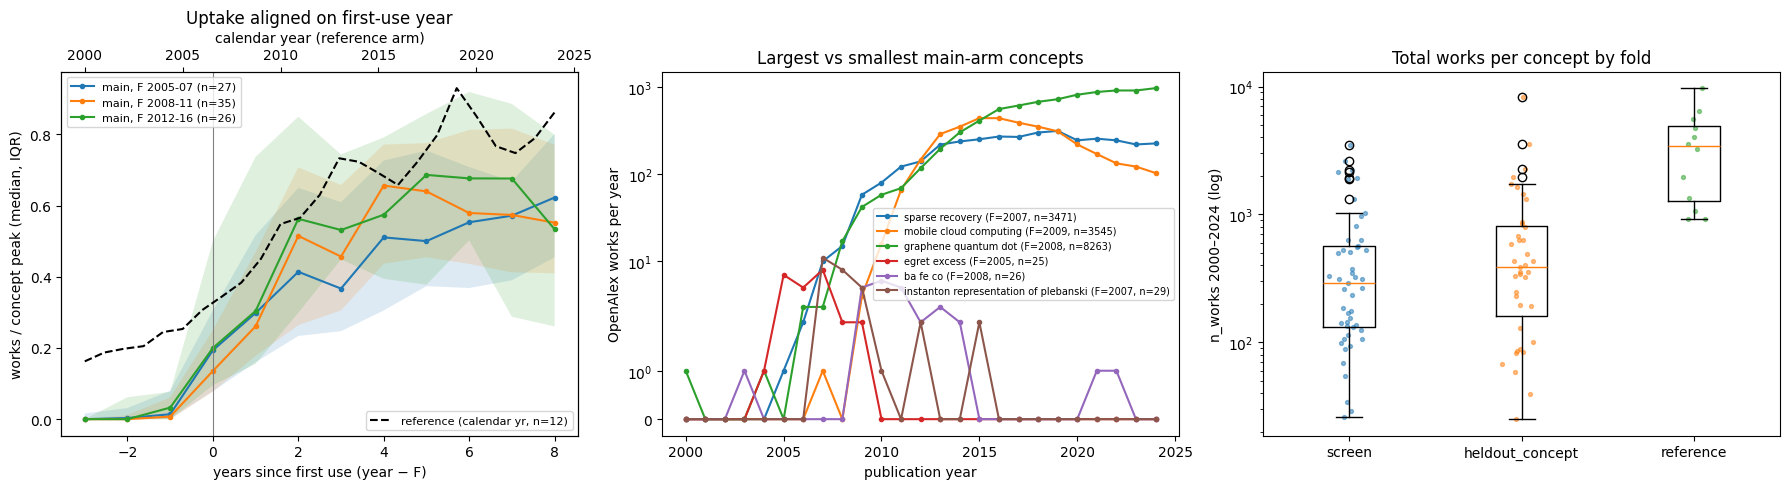

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) event-time aligned, peak-normalised median trajectories by F band + reference arm in calendar time
ax = axes[0]
rel = np.arange(-3, 9)  # F <= 2016, so F+8 <= 2024 stays inside the 2000-2024 window
for band, g in df[df.fold != "reference"].groupby("F_band"):
    M = []
    for _, r in g.iterrows():
        c = r["_counts"] / max(r["_counts"].max(), 1)
        M.append([c[YEARS.index(r.F + k)] if (r.F + k) in YEARS else np.nan for k in rel])
    M = np.array(M)
    med = np.nanmedian(M, 0)
    ax.plot(rel, med, marker="o", ms=3, label=f"main, F {band} (n={len(g)})")
    ax.fill_between(rel, np.nanpercentile(M, 25, 0), np.nanpercentile(M, 75, 0), alpha=0.15)
ref = df[df.fold == "reference"]
if len(ref):
    R = np.array([r / max(r.max(), 1) for r in ref["_counts"]])
    ax2 = ax.twiny()
    ax2.plot(YEARS, np.median(R, 0), "k--", label=f"reference (calendar yr, n={len(ref)})")
    ax2.set_xlabel("calendar year (reference arm)")
    ax2.legend(loc="lower right", fontsize=8)
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("years since first use (year − F)")
ax.set_ylabel("works / concept peak (median, IQR)")
ax.set_title("Uptake aligned on first-use year")
ax.legend(loc="upper left", fontsize=8)

# (2) example trajectories: largest and smallest main-arm concepts
ax = axes[1]
main_arm = df[df.fold != "reference"].sort_values("n_works")
for _, r in pd.concat([main_arm.tail(3), main_arm.head(3)]).iterrows():
    ax.plot(YEARS, r["_counts"], marker=".", label=f'{r.phrase} (F={int(r.F)}, n={r.n_works})')
ax.set_yscale("symlog")
ax.set_xlabel("publication year")
ax.set_ylabel("OpenAlex works per year")
ax.set_title("Largest vs smallest main-arm concepts")
ax.legend(fontsize=7)

# (3) total works per concept by fold
ax = axes[2]
folds = [f for f in ["screen", "heldout_concept", "reference"] if f in set(df.fold)]
ax.boxplot([df[df.fold == f].n_works for f in folds], tick_labels=folds)
for i, f in enumerate(folds, 1):
    ax.scatter(np.random.default_rng(0).normal(i, 0.05, (df.fold == f).sum()), df[df.fold == f].n_works, s=8, alpha=0.5)
ax.set_yscale("log")
ax.set_ylabel("n_works 2000–2024 (log)")
ax.set_title("Total works per concept by fold")

plt.tight_layout()
plt.show()